In [45]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly
import streamlit as st
import joblib

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [46]:
## Read *.csv file into pandas DataFrame
FILEPATH = "C:\\Users\\audre\\Downloads\\differentiated+thyroid+cancer+recurrence\\Thyroid_Diff.csv"
df = pd.read_csv(FILEPATH)
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [47]:
st.title = "Thyroid Cancer Recurrence Data Prediction"

## 2.2 Summary Statistics

In [48]:
## Understand the type of variable for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

In [49]:
## Check for missing data
df.isna().sum()

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

In [50]:
## Describe data distribution
df.describe(include="all")

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383.000000,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,NaN,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,NaN,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,NaN,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275
mean,40.866841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.134494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
## Drop any duplicated data
df = df.drop_duplicates()

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

In [52]:
## Understanding distribution of target
col_y = 'Recurred'

### 2.3.1.2 Understanding distribution of features

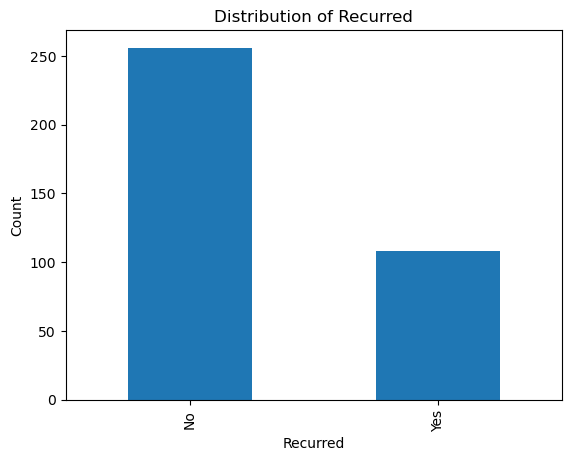

In [53]:
## Understanding distribution of features
df['Recurred'].value_counts().plot(kind='bar')
plt.title('Distribution of Recurred')
plt.xlabel('Recurred')
plt.ylabel('Count')
plt.show()

### 2.3.2 Understanding relationship between variables

In [54]:
## Check datatypes for each column
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all␣ categorical columns
## Display correlation matrix
df_corr = df[col_numeric].corr()
df_corr


,Age
Age,1.0


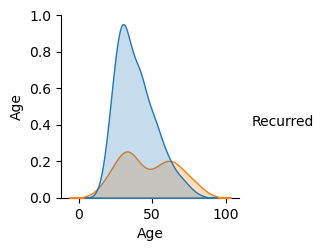

In [55]:
## Plot pairplot
sns.pairplot(df, hue=col_y)
plt.show()


# 3. Data Preparation

## 3.1 Data Cleaning

In [56]:
## one hot encoding 
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

df["Recurred"] = label.fit_transform(df["Recurred"])

In [57]:
# Remove some less useful columns
df = df.drop(["Gender", "Smoking", "Hx Smoking", "Stage"], axis=1)

In [58]:
X = df.drop("Recurred", axis=1)
y = df["Recurred"]

# Convert categorical data into numbers
X = pd.get_dummies(X, drop_first=True)

## 3.2 Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
## Check datatypes for each column
col_categorical = df.select_dtypes(include=['object']).columns ## Select all␣categorical columns
## Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}')


Hx Radiothreapy (2): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Thyroid Function (5): <ArrowStringArray>
[                  'Euthyroid',    'Clinical Hyperthyroidism',
     'Clinical Hypothyroidism', 'Subclinical Hyperthyroidism',
  'Subclinical Hypothyroidism']
Length: 5, dtype: str
Physical Examination (5): <ArrowStringArray>
[ 'Single nodular goiter-left',         'Multinodular goiter',
 'Single nodular goiter-right',                      'Normal',
              'Diffuse goiter']
Length: 5, dtype: str
Adenopathy (6): <ArrowStringArray>
['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior']
Length: 6, dtype: str
Pathology (4): <ArrowStringArray>
['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell']
Length: 4, dtype: str
Focality (2): <ArrowStringArray>
['Uni-Focal', 'Multi-Focal']
Length: 2, dtype: str
Risk (3): <ArrowStringArray>
['Low', 'Intermediate', 'High']
Length: 3, dtype: str
T (7): <ArrowStringArray>
['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'

C:\Users\audre\AppData\Local\Temp\ipykernel_39156\715867812.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_categorical = df.select_dtypes(include=['object']).columns ## Select all␣categorical columns


# 4. Modelling


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        51
           1       0.95      0.91      0.93        22

    accuracy                           0.96        73
   macro avg       0.96      0.94      0.95        73
weighted avg       0.96      0.96      0.96        73

Accuracy : 0.958904109589041
Precision: 0.9523809523809523
Recall   : 0.9090909090909091
F1 Score : 0.9302325581395349


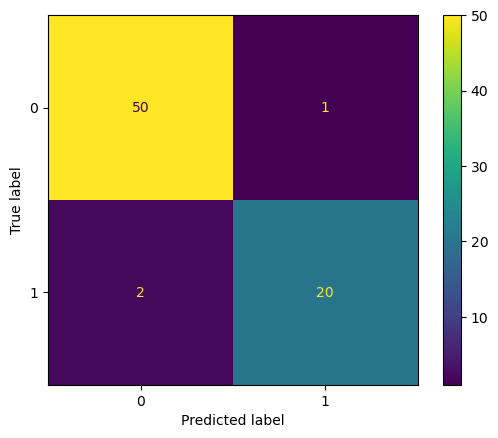

In [61]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
print("\n===== Logistic Regression =====")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

prediction = lr.predict(X_test)

print(classification_report(y_test, prediction))

print("Accuracy :", accuracy_score(y_test, prediction))
print("Precision:", precision_score(y_test, prediction))
print("Recall   :", recall_score(y_test, prediction))
print("F1 Score :", f1_score(y_test, prediction))

ConfusionMatrixDisplay.from_predictions(y_test, prediction)
plt.show()


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        51
           1       0.95      0.91      0.93        22

    accuracy                           0.96        73
   macro avg       0.96      0.94      0.95        73
weighted avg       0.96      0.96      0.96        73

Accuracy : 0.958904109589041
Precision: 0.9523809523809523
Recall   : 0.9090909090909091
F1 Score : 0.9302325581395349


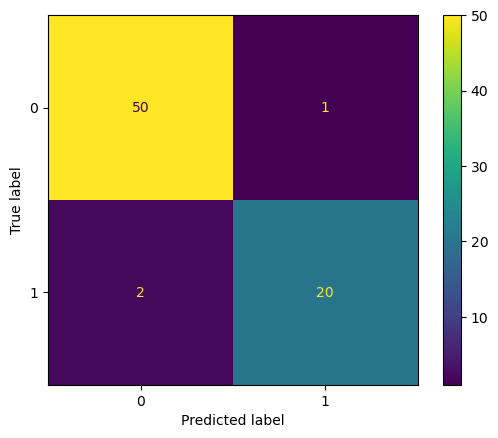

In [62]:
## Random Forest
from sklearn.ensemble import RandomForestClassifier
print("\n===== Random Forest =====")

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

prediction = rf.predict(X_test)

print(classification_report(y_test, prediction))

print("Accuracy :", accuracy_score(y_test, prediction))
print("Precision:", precision_score(y_test, prediction))
print("Recall   :", recall_score(y_test, prediction))
print("F1 Score :", f1_score(y_test, prediction))

ConfusionMatrixDisplay.from_predictions(y_test, prediction)
plt.show()

In [63]:
## Hyperparameters tuning

param_dist = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5,10]

}

search = RandomizedSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_distributions=param_dist,

    cv=5,

    scoring="recall",

    n_iter=10,

    n_jobs=-1,

    random_state=42
)

search.fit(X_train,y_train)

print(search.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}


### 4.2 Train Model

In [64]:
## Train
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)
rs_rf.fit(X_train, y_train)

print("Best Parameters:")
print(rs_rf.best_params_)

print("Best Recall:")
print(rs_rf.best_score_)


Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Best Recall:
0.8967320261437909


# 5. Model Evaluation

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        51
           1       0.95      0.91      0.93        22

    accuracy                           0.96        73
   macro avg       0.96      0.94      0.95        73
weighted avg       0.96      0.96      0.96        73

Accuracy : 0.958904109589041
Precision: 0.9523809523809523
Recall   : 0.9090909090909091
F1 Score : 0.9302325581395349
[[50  1]
 [ 2 20]]


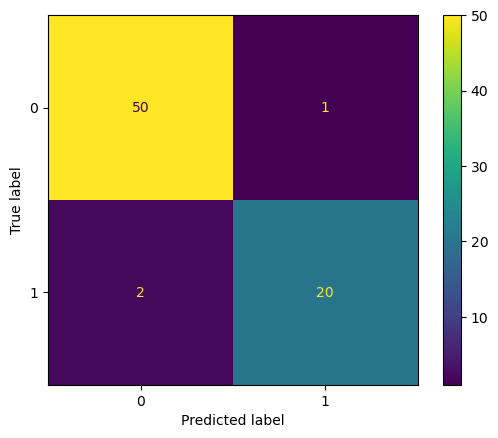

In [65]:
## Evaluate model
best_model = rs_rf.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [66]:
best_model = search.best_estimator_

prediction = best_model.predict(X_test)

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        51
           1       0.95      0.91      0.93        22

    accuracy                           0.96        73
   macro avg       0.96      0.94      0.95        73
weighted avg       0.96      0.96      0.96        73



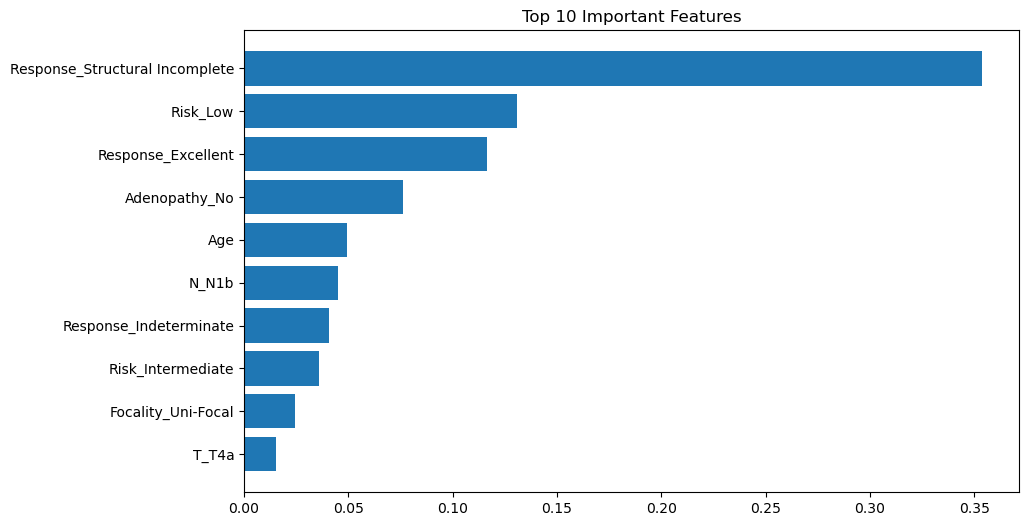

In [67]:
## Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

Justification of using this evaluation metric:
As the dataset is a medical classification problem, failing to identify a patient with recurrent thyroid cancer (false negative) can have more serious consequences than wrongly predicting recurrance (false positive). Missing actual positive cases can cause more severe consequences than false positives.

In [68]:
## New data
import joblib
joblib.dump(best_model, "thyroid_model.pkl")
import joblib
model = joblib.load("thyroid_model.pkl")

## Predict
new_patient = pd.DataFrame({

    "Age":[45],
    "Gender":["F"],
    "Smoking":["No"],
    "Hx Smoking":["No"],
    "Hx Radiothreapy":["No"],
    "Thyroid Function":["Euthyroid"],
    "Physical Examination":["Multinodular goiter"],
    "Adenopathy":["No"],
    "Pathology":["Papillary"],
    "Focality":["Uni-Focal"],
    "Risk":["Low"],
    "T":["T2"],
    "N":["N0"],
    "M":["M0"],
    "Response":["Excellent"]

})

new_patient = pd.get_dummies(new_patient)

new_patient = new_patient.reindex(
    columns=X_train.columns,
    fill_value=0
)

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Predicted Result: Recurred")
else:
    print("Predicted Result: Not Recurred")

Predicted Result: Not Recurred


In [ ]:
## Get the best Random Forest model
best_model = rs_rf.best_estimator_

## Save the trained model
joblib.dump(best_model, "Thyroid_Diff_Model.pkl")

print("Model saved!")

## Testing model
test_model = joblib.load("Thyroid_Diff_Model.pkl")

print(type(test_model)) ## Ensure that we are using the right model and not the dataset
print(test_model.feature_names_in_)

Model saved!
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
['Age' 'Hx Radiothreapy_Yes' 'Thyroid Function_Clinical Hypothyroidism'
 'Thyroid Function_Euthyroid'
 'Thyroid Function_Subclinical Hyperthyroidism'
 'Thyroid Function_Subclinical Hypothyroidism'
 'Physical Examination_Multinodular goiter' 'Physical Examination_Normal'
 'Physical Examination_Single nodular goiter-left'
 'Physical Examination_Single nodular goiter-right' 'Adenopathy_Extensive'
 'Adenopathy_Left' 'Adenopathy_No' 'Adenopathy_Posterior'
 'Adenopathy_Right' 'Pathology_Hurthel cell' 'Pathology_Micropapillary'
 'Pathology_Papillary' 'Focality_Uni-Focal' 'Risk_Intermediate' 'Risk_Low'
 'T_T1b' 'T_T2' 'T_T3a' 'T_T3b' 'T_T4a' 'T_T4b' 'N_N1a' 'N_N1b' 'M_M1'
 'Response_Excellent' 'Response_Indeterminate'
 'Response_Structural Incomplete']


Assumptions:
The dataset accurately contains data of Thyroid cancer patients and that the information is correctly recorded and complete.
Patient are independent observations (The previous patient's results does not affect or have any association to the next patient's result)
